<div style="text-align: justify; max-width: 90ch">

# Lecture 02a: Embeddings and cosine similarity

**Status: Mandatory reading.**

Lecture 1 ended with a chain that answers from the model's memory. Lecture 2 makes it answer from **your documents**, the Python course notes.
The first problem is finding the right notes for a question, and matching words is not enough: a student asks "how do I get rid of empty rows?", the notes say "`dropna` removes missing values".
An **embedding model** gives texts with similar *meaning* similar numbers.

**What this notebook covers**

- An **embedding**: a text as a vector, computed by a second model.
- **Cosine similarity**, and how it differs from the Euclidean distance of k-NN.
- An interactive plot of words as arrows: cosine is the angle between them.
- A similarity heatmap, where meaning shows up as blocks.
- Meaning versus words: a keyword search that fails and an embedding search that works.
- Blind spots: word order, and languages the model does not know.

</div>

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
import plotly.graph_objects as go
from dotenv import load_dotenv

In [2]:
# --- Course configuration: edit TIER only; settings in .env (Read: 01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
load_dotenv(REPO / ".env")  # load your .env settings: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-02-rag"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

## 1. Text in, numbers out

The course's embedding model is [`nomic-embed-text`](https://ollama.com/library/nomic-embed-text), pulled in guide `01c_ollama`.
It is a separate, small model (274 MB): it reads a text and returns a **vector**, a fixed-length list of numbers, instead of an answer.
The chat model writes; the embedding model only measures.

</div>

In [3]:
check_ollama(OLLAMA_HOST, [EMBED_MODEL])
client = ollama.Client(host=OLLAMA_HOST)

response = client.embed(
    model=EMBED_MODEL, input="How do I drop rows with missing values in pandas?"
)
vector = response.embeddings[0]

print(len(vector), "numbers:", np.round(vector[:6], 3), "...")

Ollama OK at http://localhost:11434; models ready: nomic-embed-text
768 numbers: [ 0.008  0.013 -0.125 -0.057  0.097  0.032] ...


<div style="text-align: justify; max-width: 90ch">

768 numbers, the model's **dimension**. Nobody reads them one by one: what matters is how the vectors of two texts compare.

| Term | Meaning |
| --- | --- |
| **embedding** | the vector a model assigns to a text; also the act of computing it |
| **dimension** | the length of the vector, fixed per model (768 here) |
| **embedding model** | a model trained so that texts with similar meaning get nearby vectors |

`input` also takes a list: one call returns one vector per text. The model card asks for task prefixes (`search_query: ` before a question, `search_document: ` before a text).
LangChain's `OllamaEmbeddings`, used from `lec_02d` on, does not add them, so the course embeds plain text everywhere, for one consistent setup.
It has a price: in example runs, prefixes raised the retrieval score of `lec_02d` (MRR) slightly.

</div>

<div style="text-align: justify; max-width: 90ch">

## 2. Cosine similarity

In lecture 10, k-NN measured **Euclidean distance**: how far apart two points are. For embeddings, the **direction** of a vector carries the meaning, so we compare directions with **cosine similarity**:
`a · b / (|a| |b|)`. It is 1 for vectors pointing the same way and 0 for vectors at right angles. In NumPy, `a @ b` is the dot product of two vectors, and the matrix product of two matrices.

</div>

In [4]:
def embed(texts):
    """Return one vector per text, as the rows of a NumPy array."""
    return np.array(client.embed(model=EMBED_MODEL, input=texts).embeddings)


def cosine(a, b):
    """Cosine similarity of two vectors: 1 means the same direction."""
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

<div style="text-align: justify; max-width: 90ch">

Picture it first with **toy vectors**: seven words, two dimensions, each with a name. The `animal` axis says how much a word is about animals, the `data` axis how much it is about data.
`pandas` scores on both, because it is an animal and a library. `cosine_table` puts every pair's cosine in one DataFrame;
we keep the columns of `pandas` and `DataFrame`.

</div>

In [5]:
def cosine_table(vectors, names):
    """Cosine similarity of every pair of vectors, as a labelled DataFrame."""
    return pd.DataFrame(
        [[cosine(a, b) for b in vectors] for a in vectors], index=names, columns=names
    ).round(2)


# Hand-made 2D vectors with named axes; a real model's 768 axes have no names
toy = pd.DataFrame(
    {
        "animal": [0.9, 1.6, 1.1, 0.6, 0.35, 0.1, 0.2],
        "data": [0.1, 0.3, 0.35, 0.6, 0.9, 0.9, 1.5],
    },
    index=["cat", "dog", "bear", "pandas", "NumPy", "DataFrame", "spreadsheet"],
)

cosine_table(toy.to_numpy(), toy.index)[["pandas", "DataFrame"]]

,pandas,DataFrame
cat,0.78,0.22
dog,0.83,0.29
bear,0.89,0.41
pandas,1.00,0.78
NumPy,0.92,0.97
DataFrame,0.78,1.00
spreadsheet,0.79,1.00


<div style="text-align: justify; max-width: 90ch">

The same vectors as arrows from the origin, drawn with [`plotly`](https://plotly.com/python/), a library for **interactive** charts:
hover over a word to see its cosine with each other word, the angle between their arrows, and their Euclidean distance. `go.Figure` starts an empty chart;
each `add_trace` adds a layer: one arrow per word, then the labels that carry the hover text.

</div>

In [6]:
def hover_text(word):
    """What the mouse shows over one word: its vector, then how it compares to the others."""
    a = toy.loc[word].to_numpy()
    rows = [f"<b>{word}</b>: vector ({a[0]}, {a[1]}), length {np.linalg.norm(a):.2f}"]
    for other in toy.index.drop(word):
        b = toy.loc[other].to_numpy()
        similarity = cosine(a, b)
        angle = np.degrees(
            np.arccos(min(similarity, 1.0))
        )  # rounding can give 1.0000001
        rows.append(
            f"{other}: cosine {similarity:.2f}, angle {angle:.0f}°, distance {np.linalg.norm(a - b):.2f}"
        )
    return "<br>".join(rows)


fig = go.Figure()

for word, (x, y) in toy.iterrows():  # one arrow per word, from the origin to its vector
    fig.add_trace(
        go.Scatter(
            x=[0, x],
            y=[0, y],
            mode="lines+markers",
            line={"color": "#4c72b0", "width": 2},
            marker={"symbol": "arrow", "size": [0, 14], "angleref": "previous"},
            hoverinfo="skip",
        )
    )

fig.add_trace(  # the word labels, which carry the hover text
    go.Scatter(
        x=toy["animal"],
        y=toy["data"],
        mode="markers+text",
        text=toy.index,
        textposition="top center",
        marker={"size": 16, "color": "rgba(0, 0, 0, 0)"},
        hovertext=[hover_text(word) for word in toy.index],
        hoverinfo="text",
    )
)

fig.update_layout(
    title="Cosine compares directions: hover over a word",
    xaxis={"title": "animal", "range": [-0.1, 1.8]},
    yaxis={"title": "data", "range": [-0.1, 1.65]},
    width=650,
    height=600,
    showlegend=False,
)
fig.update_yaxes(scaleanchor="x")  # same scale on both axes, so the angles are true

fig.show()

<div style="text-align: justify; max-width: 90ch">

Hover over `pandas`, then `DataFrame`:

- **Neighbours of pandas.** One on each side: `bear` (0.89) among the animals, `NumPy` (0.92) among the data words. `pandas` points between the two groups.
- **Direction, not length.** `spreadsheet`'s arrow is much longer than `DataFrame`'s, 0.61 apart in Euclidean distance, yet they point the same way:
  cosine 1.00, an angle of 1°. To cosine they mean the same, and so do `cat` and `dog` (0.73 apart, 4°).
- **Far apart.** `cat` and `DataFrame` meet at 77°: cosine 0.22.

A real embedding model does the same in 768 dimensions, learned from text, none with a name. The next cell asks `nomic-embed-text` about these words and three more:
`panda`, `bamboo` and `Excel`.

</div>

In [7]:
words = [
    "cat",
    "dog",
    "bear",
    "panda",
    "bamboo",
    "pandas",
    "DataFrame",
    "NumPy",
    "spreadsheet",
    "Excel",
]

cosine_table(embed(words), words)[["pandas", "DataFrame"]].sort_values(
    "pandas", ascending=False
)

,pandas,DataFrame
pandas,1.00,0.42
panda,0.93,0.42
bear,0.62,0.35
dog,0.57,0.41
bamboo,0.54,0.38
cat,0.51,0.32
Excel,0.47,0.50
NumPy,0.46,0.48
DataFrame,0.42,1.00
spreadsheet,0.41,0.47


<div style="text-align: justify; max-width: 90ch">

The real values are closer together, and even unrelated words score well above 0: every vector shares a common direction, so only the order means something.

- **pandas**: are its nearest words the animals or the data words, and where does `DataFrame` land? In one example run `panda` came first (0.93), the animals and `bamboo` next, and `DataFrame` far down (0.42):
  the model reads `pandas` as the plural of the animal.
- **DataFrame**: are its nearest words the data words (`Excel`, `NumPy`, `spreadsheet`), as in the toy picture?

A single word carries no context, so the model reads it in its most common sense. That is why the course embeds sentences and chunks of notes, never single words.

</div>

In [8]:
question = "How do I remove rows with missing values from a DataFrame?"
candidates = [
    "Use dropna to delete incomplete records from a table.",
    "The recipe needs two eggs and a cup of flour.",
]

question_vector, *candidate_vectors = embed(
    [question, *candidates]
)  # first vector, then the rest

pd.DataFrame(
    {
        "candidate": candidates,
        "cosine": [round(cosine(question_vector, v), 3) for v in candidate_vectors],
    }
)

,candidate,cosine
0,Use dropna to delete incomplete records from a...,0.570
1,The recipe needs two eggs and a cup of flour.,0.371


<div style="text-align: justify; max-width: 90ch">

The paraphrase scores clearly higher than the recipe (0.57 against 0.37 in one example run), but the recipe does **not** score 0:
every English sentence shares something with every other. Cosine values only mean something **relative to each other**, so a search ranks candidates instead of applying a fixed threshold.

</div>

<div style="text-align: justify; max-width: 90ch">

## 3. A similarity heatmap

Eight sentences, four topics, two sentences each. Scaling every vector to length 1 turns cosine similarity into a plain dot product,
so one matrix product computes all 64 similarities at once.

</div>

In [9]:
sentences = [
    "How do I drop rows with missing values in pandas?",
    "Use dropna to delete incomplete records from a DataFrame.",
    "KNN classifies a point by the votes of its nearest neighbours.",
    "A k-nearest-neighbours model looks at the closest training examples.",
    "Preheat the oven to 180 degrees and grease the tin.",
    "The recipe needs two eggs and a cup of flour.",
    "Our team won the football match on Saturday.",
    "The striker scored twice in the second half.",
]

vectors = embed(sentences)
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
similarity = unit @ unit.T

similarity.shape

(8, 8)

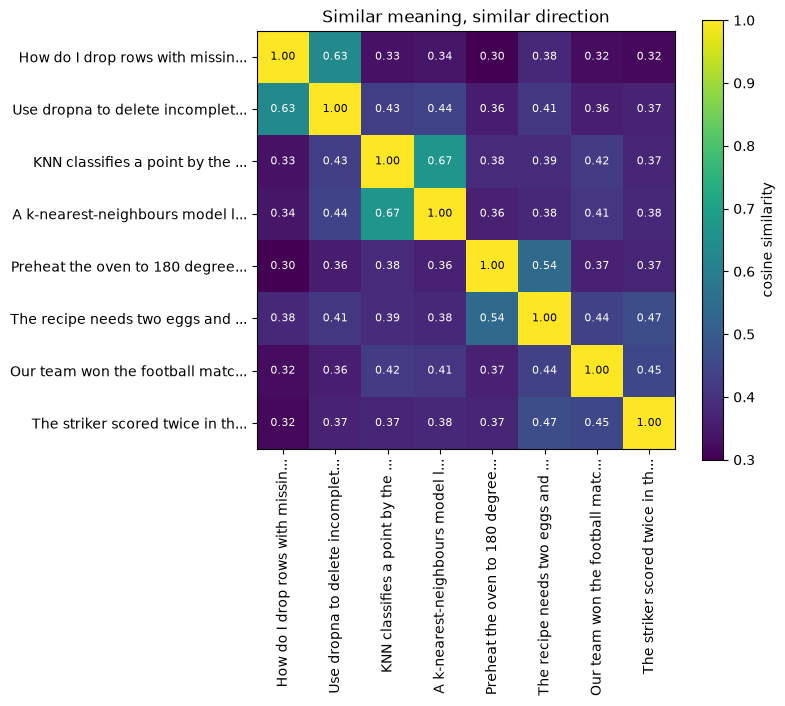

In [10]:
labels = [s[:30] + "..." for s in sentences]

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(similarity, cmap="viridis", vmin=0.3, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        color = "black" if similarity[i, j] > 0.8 else "white"
        ax.text(
            j,
            i,
            f"{similarity[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=color,
        )

fig.colorbar(image, label="cosine similarity")
ax.set_title("Similar meaning, similar direction")
plt.tight_layout()

plt.show()

<div style="text-align: justify; max-width: 90ch">

### ⏸ Pause point

Look for 2×2 blocks along the diagonal, one per topic: which stand out, and which barely do? Find the highest pair *outside* the blocks:
is it a real relationship, or a coincidence such as a shared word? Then look at the two k-NN sentences: they share almost no words ("classifies", "votes" against "looks at", "closest").
Do they still score high?

</div>

<div style="text-align: justify; max-width: 90ch">

## 4. Meaning, not words

Before embeddings, search meant **keyword matching**: score each document by the words it shares with the question. It works when the student uses the words of the notes, and fails when they do not.

</div>

In [11]:
# WRONG for paraphrased questions: rank the documents by the words they share
documents = [
    "Use dropna to delete incomplete records from a DataFrame.",
    "Rows and columns of a table can have names.",
    "Scale the features before fitting a distance-based model.",
    "The recipe needs two eggs and a cup of flour.",
]
question = "How do I get rid of rows that have empty cells?"


def shared_words(a, b):
    """Number of distinct words two texts have in common."""
    return len(set(a.lower().strip("?.").split()) & set(b.lower().strip("?.").split()))


pd.DataFrame(
    {
        "document": documents,
        "shared words": [shared_words(question, d) for d in documents],
    }
).sort_values("shared words", ascending=False)

,document,shared words
1,Rows and columns of a table can have names.,3
3,The recipe needs two eggs and a cup of flour.,1
0,Use dropna to delete incomplete records from a...,0
2,Scale the features before fitting a distance-b...,0


In [12]:
# RIGHT for paraphrased questions: rank the documents by meaning
question_vector, *document_vectors = embed([question, *documents])

pd.DataFrame(
    {
        "document": documents,
        "cosine": [round(cosine(question_vector, v), 3) for v in document_vectors],
    }
).sort_values("cosine", ascending=False)

,document,cosine
0,Use dropna to delete incomplete records from a...,0.581
1,Rows and columns of a table can have names.,0.496
3,The recipe needs two eggs and a cup of flour.,0.401
2,Scale the features before fitting a distance-b...,0.343


<div style="text-align: justify; max-width: 90ch">

Keyword search picks the sentence that shares "rows", "have" and "of". Check which sentence the embedding search ranks first:
in example runs, the `dropna` sentence, which shares no word with the question at all. That is why RAG systems search with embeddings:
people describe the same thing in different words. Real keyword search, such as [BM25](https://en.wikipedia.org/wiki/Okapi_BM25),
ignores common words like "of", and it still wins where the exact word matters.

### ⏸ Pause point

Is there a kind of question where matching the exact word would beat matching meaning? Think of names that only exist in code.
`lec_02b` meets one.

</div>

<div style="text-align: justify; max-width: 90ch">

## 5. Blind spots

An embedding is a summary of meaning, and a summary loses things. Two losses to know before trusting one:

</div>

In [13]:
a, b = embed(["The cat sat on the mat.", "The mat sat on the cat."])
print(f"{cosine(a, b):.3f}")

0.941


<div style="text-align: justify; max-width: 90ch">

Two sentences with opposite meanings: compare their cosine with the values above (0.94 in one example run, higher than any paraphrase pair).
The model captures *what* a sentence is about more than *who did what to whom*. Good enough for finding the right notes;
a reason never to use similarity as a check that an answer is correct.

</div>

In [14]:
note, english, greek = embed(
    [
        "Use dropna to delete incomplete records from a DataFrame.",
        "How do I drop rows with missing values in pandas?",
        "Πώς διαγράφω γραμμές με κενές τιμές σε ένα DataFrame του pandas;",
    ]
)

print(f"English question: {cosine(note, english):.3f}")
print(f"Greek question:   {cosine(note, greek):.3f}")

English question: 0.632
Greek question:   0.510


<div style="text-align: justify; max-width: 90ch">

Compare the two lines: the same question in Greek scores lower, in one example run 0.51 against 0.63, about halfway down to the unrelated sentences of sections 2 and 3.
`nomic-embed-text` was trained mostly on English: the chat model understands Greek, the embedding model much less, so a Greek question is more likely to retrieve the wrong notes.
That is the *languages* requirement of `lec_01b` failing in a model nobody thought to check: **every model in the system** has to meet the requirements.
A multilingual embedding model such as [`bge-m3`](https://ollama.com/library/bge-m3) (1.2 GB, 100+ languages) is built for this;
the course keeps `nomic-embed-text` because its notes and questions are in English.

</div>

<div style="text-align: justify; max-width: 90ch">

## Recap

- An **embedding model** turns a text into a fixed-length vector; it is a second model in the system, with its own requirements.
- **Cosine similarity** compares directions; its values mean something only relative to each other.
- Embeddings match **meaning**, not words, which is why they beat keyword search for questions in the student's own words.
- They blur word order, and they only work in the languages they were trained on.

**Next: `lec_02b`**, which embeds the course notes and uses these vectors to hand the model the right pages to answer from.

</div>